**Background:**


The sunspot number refers to the count of sunspots visible on the Sun's surface. Sunspots are temporary, dark areas caused by magnetic activity, and their number fluctuates in an approximately 11-year cycle known as the solar cycle. During periods of solar maximum (when sunspot activity is high), the Sun's magnetic activity is stronger, and during solar minimum (when sunspot activity is low), it is weaker.

Sunspot numbers are used to track solar activity, and historically, they have been correlated with changes in Earth's temperature. While the direct impact on Earth's climate is complex, solar radiation emitted by the Sun can vary with sunspot activity. When sunspot numbers are high, the Sun emits slightly more energy, which can have a small warming effect on Earth. Conversely, when sunspot activity is low, the Sun's output might decrease slightly, leading to a cooling effect.

However, the sunspot number alone doesn't explain the variations in Earth's temperature. Modern climate change is primarily driven by greenhouse gases, and the sunspot cycle has only a minor effect on Earth's overall long-term temperature. Studies suggest that changes in solar radiation due to sunspot cycles are not enough to account for the significant warming observed over the last century. 

Moreover, Companies in industries such as agriculture, energy, and insurance rely on accurate climate predictions to manage risk. If temperature anomalies are primarily driven by sunspot activity, businesses would focus on solar cycle predictions. However, if CO₂ levels have a stronger causal effect, regulatory policies (e.g., carbon taxes) and sustainability efforts become more critical strategic factors.

I will test this with both predictive and causal analysis understand which factor has the higher causal influence on temperature anomalies.

**STEP 1**

DATA COLLECTION

In [1]:
#pip install requests


Data source : https://solarscience.msfc.nasa.gov/greenwch/spot_num.txt

In [2]:
import pandas as pd
import requests

# URL of the data file
url = "https://solarscience.msfc.nasa.gov/greenwch/spot_num.txt"


response = requests.get(url)
data = response.text


lines = data.split("\n")
parsed_data = []

for line in lines:
    parts = line.split()
    if len(parts) == 4:  
        try:
            year, month, ssn, dev = parts
            parsed_data.append([int(year), int(month), float(ssn), float(dev)])
        except ValueError:
            continue  


df = pd.DataFrame(parsed_data, columns=["Year", "Month", "SSN", "Deviation"])


csv_filename = "sunspot_data.csv"
df.to_csv(csv_filename, index=False)



print(f"Files saved: {csv_filename}")


Files saved: sunspot_data.csv


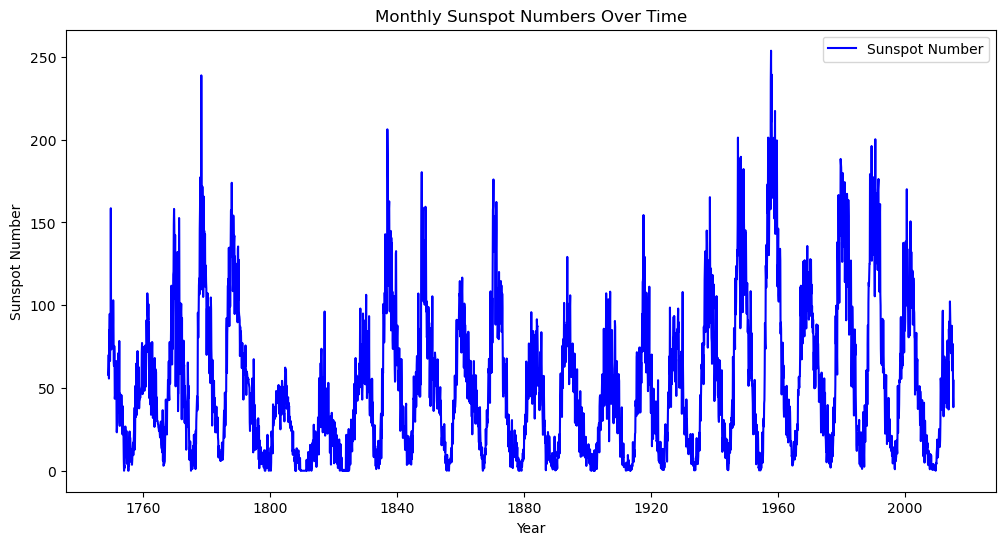

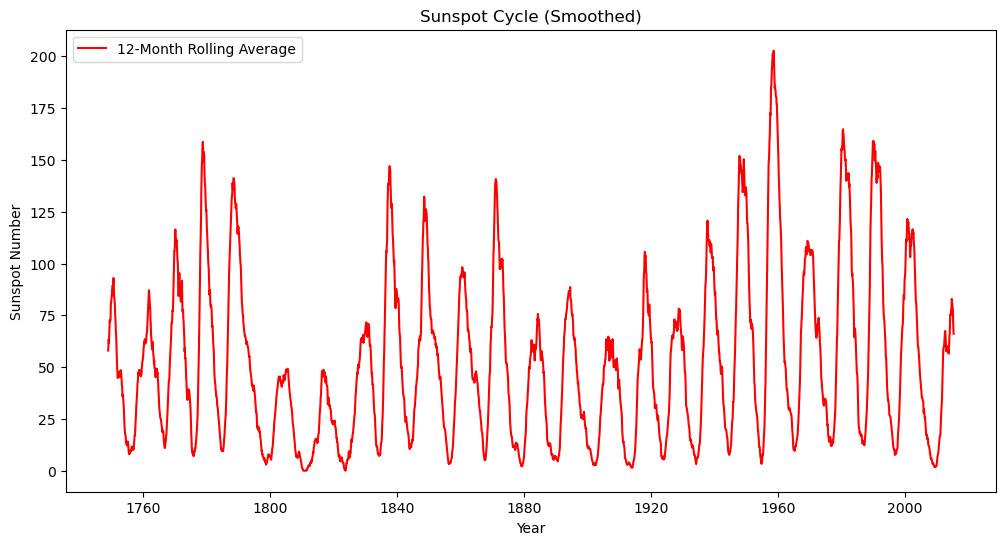

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("sunspot_data.csv")

# creating a 'date' column for time-series visualization
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(day=1))

# plot SSN over time
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["SSN"], label="Sunspot Number", color="blue")
plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.title("Monthly Sunspot Numbers Over Time")
plt.legend()
plt.show()



# rolling average to see ssn cycles
df["SSN_Rolling"] = df["SSN"].rolling(window=12, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["SSN_Rolling"], label="12-Month Rolling Average", color="red")
plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.title("Sunspot Cycle (Smoothed)")
plt.legend()
plt.show()

sunspot data collected from years 1749 to 2015 



In [4]:
df.head(5)

,Year,Month,SSN,Deviation,Date,SSN_Rolling
0,1749,1,58.0,24.1,1749-01-01,58.000000
1,1749,2,62.6,25.1,1749-02-01,60.300000
2,1749,3,70.0,26.6,1749-03-01,63.533333
3,1749,4,55.7,23.6,1749-04-01,61.575000
4,1749,5,85.0,29.4,1749-05-01,66.260000


Temperature anomalies : source - https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Complete_TAVG_complete.txt



Temperature Anomalies - Main Outcome Variable

In [5]:
import csv

# read the content of the text file
with open('Complete_TAVG_complete.txt', 'r') as file:
    lines = file.readlines()

# process the lines by replacing spaces with commas
processed_lines = []
for line in lines:
    # skip header line
    if line.startswith('%'):
        continue
    # replace many spaces with a comma
    processed_line = ','.join(line.split())
    processed_lines.append(processed_line)

with open('converted_data_temperature_anomalies.csv', 'w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    
    writer.writerow([
        'Year', 'Month', 'Monthly Anomaly', 'Monthly Uncertainty', 
        'Annual Anomaly', 'Annual Uncertainty', 
        'Five-year Anomaly', 'Five-year Uncertainty', 
        'Ten-year Anomaly', 'Ten-year Uncertainty', 
        'Twenty-year Anomaly', 'Twenty-year Uncertainty'
    ])
    
    for line in processed_lines:
        writer.writerow(line.split(','))

print("CSV file has been created successfully!")


CSV file has been created successfully!


In [6]:
import pandas as pd

df1 = pd.read_csv('converted_data_temperature_anomalies.csv')
if df1.iloc[0].isna().all():
    df1 = df1.drop(index=0)
df1.head() #starts from 1750
df1.tail() #ends at 2024

,Year,Month,Monthly Anomaly,Monthly Uncertainty,Annual Anomaly,Annual Uncertainty,Five-year Anomaly,Five-year Uncertainty,Ten-year Anomaly,Ten-year Uncertainty,Twenty-year Anomaly,Twenty-year Uncertainty
3296,2024.0,8.0,1.935,0.054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3297,2024.0,9.0,1.732,0.080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3298,2024.0,10.0,2.000,0.116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3299,2024.0,11.0,1.888,0.176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3300,2024.0,12.0,1.940,0.145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df1['Monthly Anomaly'].isna().sum()


1

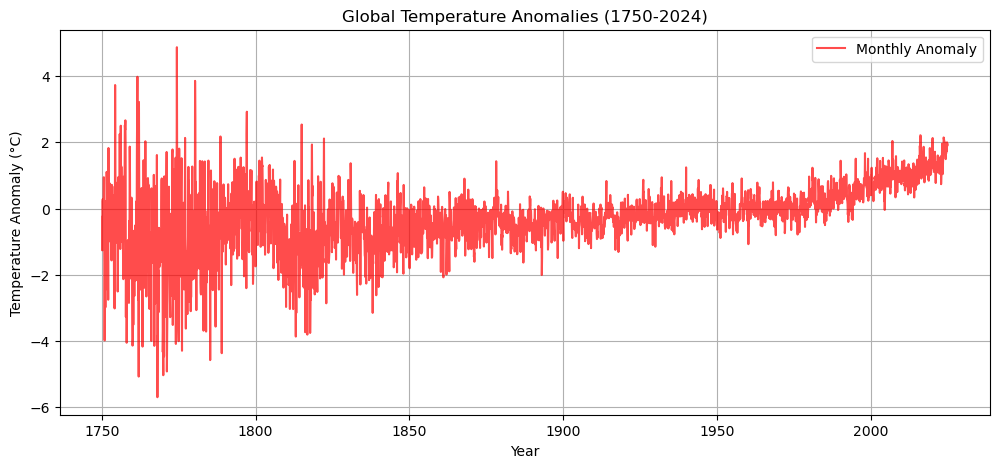

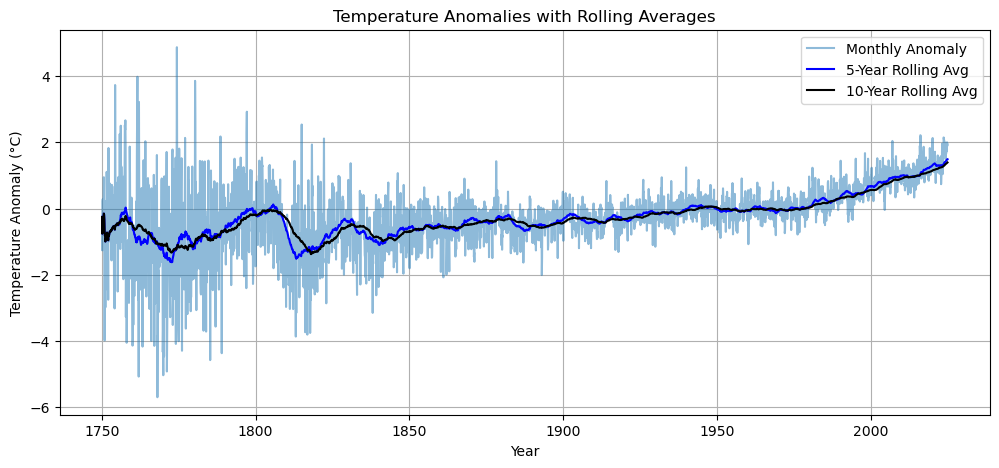

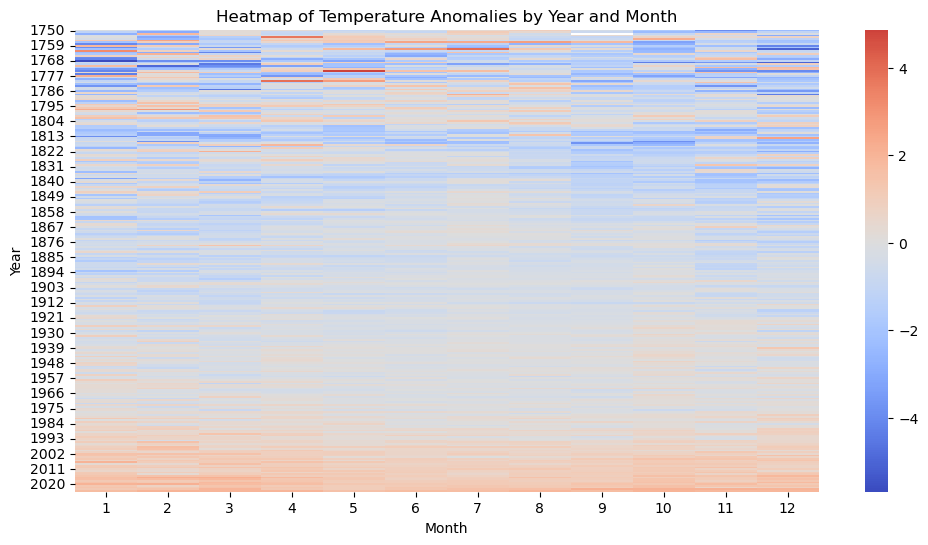

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('converted_data_temperature_anomalies.csv')
if df.iloc[0].isna().all():
    df = df.drop(index=0)

df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

plt.figure(figsize=(12, 5))
plt.plot(df['Year'] + df['Month'] / 12, df['Monthly Anomaly'], label='Monthly Anomaly', color='red', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Temperature Anomalies (1750-2024)')
plt.legend()
plt.grid()
plt.show()

df['5Y_Rolling'] = df['Monthly Anomaly'].rolling(window=60, min_periods=1).mean()
df['10Y_Rolling'] = df['Monthly Anomaly'].rolling(window=120, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Year'] + df['Month'] / 12, df['Monthly Anomaly'], alpha=0.5, label='Monthly Anomaly')
plt.plot(df['Year'] + df['Month'] / 12, df['5Y_Rolling'], label='5-Year Rolling Avg', color='blue')
plt.plot(df['Year'] + df['Month'] / 12, df['10Y_Rolling'], label='10-Year Rolling Avg', color='black')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Temperature Anomalies with Rolling Averages')
plt.legend()
plt.grid()
plt.show()

pivot_table = df.pivot(index='Year', columns='Month', values='Monthly Anomaly')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='coolwarm', center=0, fmt='.2f')
plt.xlabel('Month')
plt.ylabel('Year')
plt.title('Heatmap of Temperature Anomalies by Year and Month')
plt.show()


Recent years show more red, indicating increasing global temperatures.

Other features - CO₂ levels, volcanic activity

Data collection of  CO2 Levels

Issue : The historical CO₂ concentration data can be a bit tricky to get before the modern monitoring began in the late 1950s

Solution : The best source for historical CO₂ levels before 1950 comes from ice core data. hence i have to join ice core data with co2 data after 1950s ( which is available ) to get the co2 emissions data .

post 1958 source :
Atmospheric carbon dioxide data from Mauna Loa Observatory since 1958
https://www.kaggle.com/datasets/ucsandiego/carbon-dioxide?select=archive.csv


pre 1958 source :
https://scrippsco2.ucsd.edu/data/atmospheric_co2/icecore_merged_products.html
has data from 13.3 CE to present, but yearly and not monthly, so need to do imputation to get monthly data 

used cubic spline interpolation

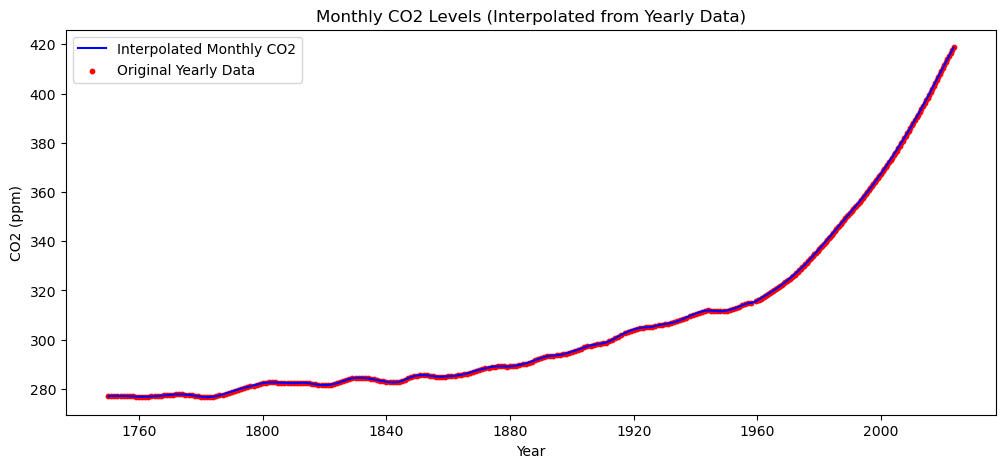

                   CO2
Date                  
1750-01-15  277.010000
1750-01-15  277.021308
1750-02-15  277.032208
1750-03-15  277.042706
1750-04-15  277.052808


In [9]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

file_path = 'spline_merged_ice_core_yearly.csv'  
co2_data = pd.read_csv(file_path)

# rename columns to match dataset
co2_data.columns = ['Year', 'CO2']

co2_data['Year'] = pd.to_numeric(co2_data['Year'], errors='coerce')

co2_data = co2_data[co2_data['Year'] >= 1750]

def convert_year_to_datetime(year):
    year_int = int(year)
    fraction = year - year_int
    month = int(round(fraction * 12)) 
    month = max(1, min(12, month))  
    return pd.Timestamp(year_int, month, 15)  

co2_data['Date'] = co2_data['Year'].apply(convert_year_to_datetime)

co2_data.set_index('Date', inplace=True)

# apply cubic spline interpolation
cs = CubicSpline(co2_data['Year'], co2_data['CO2'])

# generate monthly time points from 1750 to the latest available year
monthly_years = np.arange(1750, co2_data['Year'].max(), 1/12)  # Steps of 1/12 for monthly data


monthly_co2_values = cs(monthly_years)

monthly_dates = [convert_year_to_datetime(y) for y in monthly_years]

monthly_co2_df = pd.DataFrame({'Date': monthly_dates, 'CO2': monthly_co2_values})

monthly_co2_df.set_index('Date', inplace=True)

monthly_co2_df.to_csv('monthly_co2_interpolated.csv', index=True)

plt.figure(figsize=(12, 5))
plt.plot(monthly_co2_df.index, monthly_co2_df['CO2'], label='Interpolated Monthly CO2', color='blue')
plt.scatter(co2_data.index, co2_data['CO2'], color='red', label='Original Yearly Data', s=10)
plt.xlabel('Year')
plt.ylabel('CO2 (ppm)')
plt.title('Monthly CO2 Levels (Interpolated from Yearly Data)')
plt.legend()
plt.show()

print(monthly_co2_df.head())


In [10]:
print(monthly_co2_df.tail())


                   CO2
Date                  
2023-01-15  417.804329
2023-02-15  418.004958
2023-03-15  418.205587
2023-04-15  418.406219
2023-05-15  418.606856


Data collection of another Feature  -> Volcanic Activity

source: The Smithsonian Institution.

Dataset : https://www.kaggle.com/datasets/jessemostipak/volcano-eruptions?select=eruptions.csv (eruptions.csv)

In [11]:
#filter for dataset from 1750 to now onwards to 2015
import pandas as pd

df = pd.read_csv('volcanic_eruptions.csv')
filtered_df = df[(df['start_year'] >= 1750) & (df['start_year'] <= 2023)]

print(filtered_df.head())
filtered_df.to_csv('filtered_volcano_data_1750to2015.csv', index=False)


   volcano_number            volcano_name  eruption_number  \
0          266030                 Soputan            22354   
1          343100              San Miguel            22355   
2          233020  Fournaise, Piton de la            22343   
3          345020      Rincon de la Vieja            22346   
4          353010              Fernandina            22347   

    eruption_category area_of_activity  vei  start_year  start_month  \
0  Confirmed Eruption              NaN  NaN      2020.0          3.0   
1  Confirmed Eruption              NaN  NaN      2020.0          2.0   
2  Confirmed Eruption              NaN  NaN      2020.0          2.0   
3  Confirmed Eruption              NaN  NaN      2020.0          1.0   
4  Confirmed Eruption              NaN  NaN      2020.0          1.0   

   start_day   evidence_method_dating  end_year  end_month  end_day  latitude  \
0       23.0  Historical Observations    2020.0        4.0      2.0     1.112   
1       22.0  Historical Observa

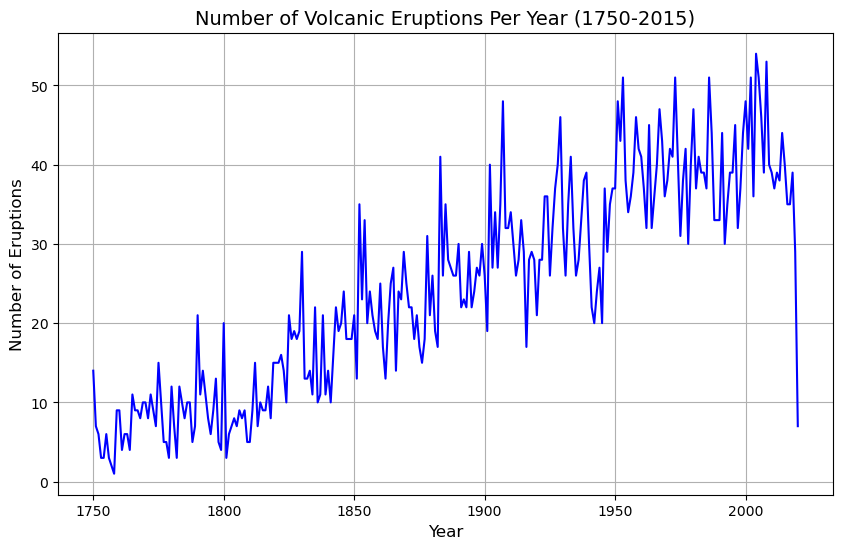

In [12]:
# group by start_year and count the number of eruptions per year
eruptions_per_year = filtered_df.groupby('start_year').size()

plt.figure(figsize=(10,6))
eruptions_per_year.plot(kind='line', color='b')
plt.title('Number of Volcanic Eruptions Per Year (1750-2015)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Eruptions', fontsize=12)
plt.grid(True)
plt.show()


JOIN ALL DATASETS

In [13]:
import pandas as pd

sunspot_df = pd.read_csv('sunspot_data.csv')
temperature_df = pd.read_csv('converted_data_temperature_anomalies.csv')
co2_df = pd.read_csv('monthly_co2_interpolated.csv', parse_dates=['Date'])
volcano_df = pd.read_csv('filtered_volcano_data_1750to2015.csv')

# convert Year and Month to a date for merging
sunspot_df['Date'] = pd.to_datetime(sunspot_df[['Year', 'Month']].assign(DAY=1))
temperature_df['Date'] = pd.to_datetime(temperature_df[['Year', 'Month']].assign(DAY=1))

merged_df = pd.merge(sunspot_df, temperature_df[['Date', 'Monthly Anomaly']], on="Date", how="inner")

co2_df['Date'] = pd.to_datetime(co2_df['Date'])

co2_df['Year'] = co2_df['Date'].dt.year
co2_df['Month'] = co2_df['Date'].dt.month

merged_df = pd.merge(merged_df, co2_df[['Year', 'Month', 'CO2']], on=['Year', 'Month'], how='left')

volcano_df['Volcanic Activity'] = 1  #  marking volcanic events

volcano_columns = ['start_year', 'Volcanic Activity', 'volcano_name', 'eruption_number', 'eruption_category', 'area_of_activity']

merged_df = pd.merge(merged_df, volcano_df[volcano_columns], left_on='Year', right_on='start_year', how='left')

merged_df['Volcanic Activity'].fillna(0, inplace=True)

merged_df.drop(columns=['start_year'], inplace=True)

merged_df.head()


/var/folders/rz/m9y4lv2543b4h866w76_dhv40000gn/T/ipykernel_79939/4174956863.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['Volcanic Activity'].fillna(0, inplace=True)


,Year,Month,SSN,Deviation,Date,Monthly Anomaly,CO2,Volcanic Activity,volcano_name,eruption_number,eruption_category,area_of_activity
0,1750,1,73.3,27.3,1750-01-01,-0.252,277.01,1,Cotopaxi,11551,Confirmed Eruption,NaN
1,1750,1,73.3,27.3,1750-01-01,-0.252,277.01,1,Arenal,11131,Confirmed Eruption,Summit and NW flank (A2 lava flows)
2,1750,1,73.3,27.3,1750-01-01,-0.252,277.01,1,Sabancaya,11745,Confirmed Eruption,NaN
3,1750,1,73.3,27.3,1750-01-01,-0.252,277.01,1,Huanquihue Group,12087,Confirmed Eruption,Achín-Niellu (Volcán Escorial)
4,1750,1,73.3,27.3,1750-01-01,-0.252,277.01,1,Antuco,11995,Confirmed Eruption,NaN


**STEP 2**

EDA + PREDICTIVE ANALYSIS

In [14]:
# check for null values in the merged DataFrame
merged_df.isnull().sum()
merged_df.drop(columns=['area_of_activity'], inplace=True)

Since monthly anomaly is outcome, i am removing the null values here


In [15]:
# remove rows where the 'Monthly Anomaly' column has null values
merged_df = merged_df.dropna(subset=['Monthly Anomaly'])

print(merged_df.head())


   Year  Month   SSN  Deviation       Date  Monthly Anomaly     CO2  \
0  1750      1  73.3       27.3 1750-01-01           -0.252  277.01   
1  1750      1  73.3       27.3 1750-01-01           -0.252  277.01   
2  1750      1  73.3       27.3 1750-01-01           -0.252  277.01   
3  1750      1  73.3       27.3 1750-01-01           -0.252  277.01   
4  1750      1  73.3       27.3 1750-01-01           -0.252  277.01   

   Volcanic Activity      volcano_name  eruption_number   eruption_category  
0                  1          Cotopaxi            11551  Confirmed Eruption  
1                  1            Arenal            11131  Confirmed Eruption  
2                  1         Sabancaya            11745  Confirmed Eruption  
3                  1  Huanquihue Group            12087  Confirmed Eruption  
4                  1            Antuco            11995  Confirmed Eruption  


In [16]:
merged_df.isnull().sum()


Year                 0
Month                0
SSN                  0
Deviation            0
Date                 0
Monthly Anomaly      0
CO2                  0
Volcanic Activity    0
volcano_name         0
eruption_number      0
eruption_category    0
dtype: int64

In [17]:

merged_df.to_csv('final_merged_dataset.csv', index=False)
merged_df.count()


Year                 77388
Month                77388
SSN                  77388
Deviation            77388
Date                 77388
Monthly Anomaly      77388
CO2                  77388
Volcanic Activity    77388
volcano_name         77388
eruption_number      77388
eruption_category    77388
dtype: int64


**Hypothesis & Treatment Variables**

**Hypothesis 1:** Sunspot number (SSN) has a significant causal impact on temperature anomalies.

**Hypothesis 2:** CO₂ concentration has a significant causal impact on temperature anomalies.

**Hypothesis 3:** Volcanic activity has a significant causal impact on temperature anomalies.



linear regression model:

In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

final_df = pd.read_csv("final_merged_dataset.csv")

X = final_df[['SSN', 'CO2', 'Volcanic Activity']]  # control features included
y = final_df['Monthly Anomaly']  # outcome variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

coefficients = model.coef_

print("Coefficients: ", coefficients)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Coefficients:  [5.61104799e-05 1.53077225e-02 0.00000000e+00]
Mean Squared Error: 0.32961079337334553


In [19]:
baseline_pred = [y.mean()] * len(y)  # predict the mean of y for all data points
baseline_mse = mean_squared_error(y, baseline_pred)
print(f"Baseline MSE: {baseline_mse}")


Baseline MSE: 0.5584487433731772


The model's Mean Squared Error (MSE) was found to be 0.3296, which is lower than the baseline MSE of 0.5584. This indicates that the model is performing better than simply predicting the mean value for all observations. 


*This also suggests that the selected features—sunspot number (SSN), CO₂ levels, and volcanic activity—possess predictive power and contribute to explaining the variations in temperature anomalies.*




Feature importance:

In [20]:
import pandas as pd
import numpy as np


coefficients = model.coef_

feature_names = ['SSN', 'CO2', 'Volcanic Activity']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (Absolute Coefficient)': np.abs(coefficients)
})

importance_df = importance_df.sort_values(by='Importance (Absolute Coefficient)', ascending=False)

print(importance_df)


             Feature  Coefficient  Importance (Absolute Coefficient)
1                CO2     0.015308                           0.015308
0                SSN     0.000056                           0.000056
2  Volcanic Activity     0.000000                           0.000000


XGBoost Mean Squared Error: 0.0955024617446955


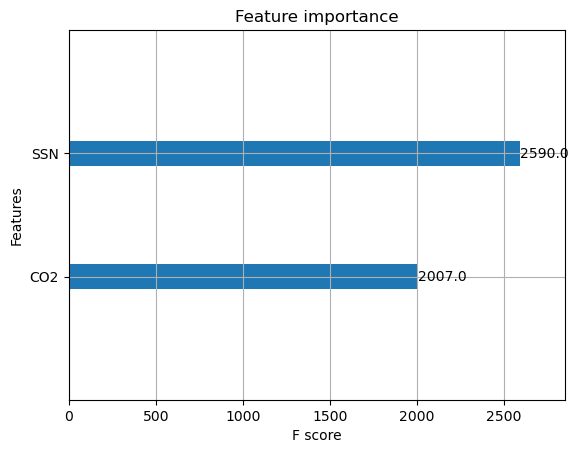

In [21]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

final_df = pd.read_csv("final_merged_dataset.csv")

X = final_df[['SSN', 'CO2', 'Volcanic Activity']]  # control
y = final_df['Monthly Anomaly']  # outcome

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"XGBoost Mean Squared Error: {mse}")

import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model)
plt.show()


**Conclusion :**

Because of a lower MSE with XGBoost, XGBT regressor is a better training model for this dataset

SSN (Solar Sunspot Number) has the highest importance (F-score = 2590), meaning it contributes the most to the model’s decisions.

CO2 (Carbon Dioxide Levels) also has high importance (F-score = 2007), but less than SSN.

It suggests that SSN is more influential than CO2 in the model’s predictions.

Volcanic eruptions is not even plotted here meaning it has no effect , this could be because it is not at all relevant OR it could be extremely collinear , so I will further test it with VIF scores.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


             Feature        VIF
0                SSN   1.012334
1                CO2   1.012334
2  Volcanic Activity  98.953946


So volcanic activity is highly collinear with other features (VIF ~99 is off the charts )

This explains why XGBoost might be ignoring it—it’s basically redundant.


Question is weather to include in causal inference model as it could be a redundant control - Highly correlated features that don’t add independent information can reduce efficiency.

Still need to test if it is a true confounder , hence I will use econml to see with both volcanic data and without to make a final conclusion.

**STEP-3**

CAUSAL INFERENCE

Visualizing Causal Graph before applying double machine learning

In [23]:
#pip install dowhy


/opt/anaconda3/lib/python3.10/site-packages/dowhy/causal_model.py:583: UserWarning: 2 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


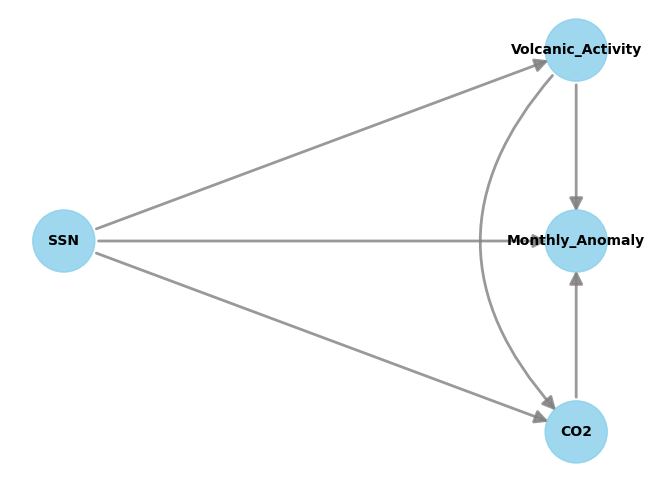

In [24]:
import dowhy
from dowhy import CausalModel


import pandas as pd

data = pd.read_csv("final_merged_dataset.csv")  



causal_graph = """
digraph {
    label="Causal Model - Initial Assumption";
    labelloc="t";
    fontsize=20;
    
    SSN -> Monthly_Anomaly
    CO2 -> Monthly_Anomaly
    Volcanic_Activity -> Monthly_Anomaly
    SSN -> Volcanic_Activity
    Volcanic_Activity -> CO2
    SSN -> CO2
}
"""

model = CausalModel(
    data=data,  
    graph=causal_graph, 
    treatment='CO2',  
    outcome='Monthly_Anomaly',  
)

model.view_model()



EconMl algorithms - Causal Analysis

In [25]:
#pip install econml


In [26]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['SSN'].to_numpy().reshape(-1, 1)  # convert to 2D
X = final_df[['CO2','Volcanic Activity']]  #controls
y = final_df['Monthly Anomaly'].to_numpy().flatten()  # ensure 1D

dml_model = LinearDML(model_t=RandomForestRegressor(),
                       model_y=RandomForestRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of SSN on Monthly Anomaly: {treatment_effect.mean()}")

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Estimated causal effect of SSN on Monthly Anomaly: -0.004415854354930461


Co-variance matrix is underdetermined. Inference will be invalid!


In [36]:
import xgboost as xgb
from econml.dml import LinearDML
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['SSN'].to_numpy().reshape(-1, 1)  
X = final_df[['CO2','Volcanic Activity']]  
y = final_df['Monthly Anomaly'].to_numpy().flatten()  

dml_model = LinearDML(model_t=xgb.XGBRegressor(objective='reg:squarederror'),
                       model_y=xgb.XGBRegressor(objective='reg:squarederror'),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of SSN on Monthly Anomaly WITH Volcanic Eruption variable: {treatment_effect.mean()}")


Estimated causal effect of SSN on Monthly Anomaly WITH Volcanic Eruption variable: -0.0009882784251261272


Co-variance matrix is underdetermined. Inference will be invalid!


The issue with the co-variance matrix arises due to multicollinearity in the data. 

Volcanic Activity and CO2 emissions were found to be highly correlated from the predictive model analysis.

So I will try without the volcanic eruption column in control variable


In [37]:


from econml.dml import LinearDML
from xgboost import XGBRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['SSN'].to_numpy().reshape(-1, 1)  
X = final_df[['CO2']]  # remove 'Volcanic Activity' due to high collinearity
y = final_df['Monthly Anomaly'].to_numpy().flatten()  

dml_model = LinearDML(model_t=XGBRegressor(),
                       model_y=XGBRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of SSN on Monthly Anomaly WITHOUT Volcanic Eruption variable: {treatment_effect.mean()}")


Estimated causal effect of SSN on Monthly Anomaly WITHOUT Volcanic Eruption variable: -0.000988278425126205


In [38]:

from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['SSN'].to_numpy().reshape(-1, 1)  
X = final_df[['CO2']]  
y = final_df['Monthly Anomaly'].to_numpy().flatten()  

dml_model = LinearDML(model_t=RandomForestRegressor(),
                       model_y=RandomForestRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of SSN on Monthly Anomaly: {treatment_effect.mean()}")

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Estimated causal effect of SSN on Monthly Anomaly: -0.004517858583535312


**LinearDML**

RandomForestRegressor: The estimated causal effect of SSN on Monthly Anomaly is -0.0044. This result suggests that for each unit increase in SSN, the Monthly Anomaly decreases by about 0.0044, after accounting for the effect of CO2 on the outcome.

XGBoost (XGBRegressor): The estimated causal effect of SSN on Monthly Anomaly is -0.00099. This is a much smaller effect than the LinearDML model.

Surprisingly XGBoost is not capturing much of the relationship at all.. Random Forest Regressor was better.


CONCLUSION:

SSN (Solar Sunspot Number) → Monthly Anomaly
Effect: -0.0044

A unit increase in SSN is associated with a 0.0044 decrease in the monthly temperature anomaly, holding CO2 constant.

The negative sign suggests that an increase in sunspot activity slightly lowers temperature anomalies, though the effect is small.

**But what about volcanic effects then?**


In [30]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['Volcanic Activity'].to_numpy().reshape(-1, 1)  
X = final_df[['SSN']]  #control
y = final_df['Monthly Anomaly'].to_numpy().flatten()  

dml_model = LinearDML(model_t=RandomForestRegressor(),
                       model_y=RandomForestRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of Volcanic Activity on Monthly Anomaly: {treatment_effect.mean()}")

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Estimated causal effect of Volcanic Activity on Monthly Anomaly: 0.0


Co-variance matrix is underdetermined. Inference will be invalid!


In [31]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['Volcanic Activity'].to_numpy().reshape(-1, 1)  
X = final_df[['SSN']]  
y = final_df['CO2'].to_numpy().flatten()  

dml_model = LinearDML(model_t=RandomForestRegressor(),
                       model_y=RandomForestRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of Volcanic Activity on CO2 levels: {treatment_effect.mean()}")

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Estimated causal effect of Volcanic Activity on CO2 levels: 0.0


Co-variance matrix is underdetermined. Inference will be invalid!


In [32]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['SSN'].to_numpy().reshape(-1, 1)  
X = final_df[['CO2']]  
y = final_df['Volcanic Activity'].to_numpy().flatten()  

dml_model = LinearDML(model_t=RandomForestRegressor(),
                       model_y=RandomForestRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of SSN on Volcanic Activity: {treatment_effect.mean()}")

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Estimated causal effect of SSN on Volcanic Activity: 0.0


By testing the Volcanic Activity variable as a treatment or outcome, My hypothesis of Volcanic Activity being a cause of C02 emissions has been disproved, or even Sun spots affecting volcanic eruption, 

It seems there is no link between Volcanic eruptions and the other features like Sunspots, Co2 emissions, temperature analomalies .



So what can we do about the temperature anomalies, ignoring the effect of sunspots on temperature anomalies ? 

*Would CO2 levels affect temperature anomalies on earth?*

In [33]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

final_df = pd.read_csv("final_merged_dataset.csv")

T = final_df['CO2'].to_numpy().reshape(-1, 1)  
X = final_df[['SSN']]  
y = final_df['Monthly Anomaly'].to_numpy().flatten()  

dml_model = LinearDML(model_t=RandomForestRegressor(),
                       model_y=RandomForestRegressor(),
                       random_state=42)

dml_model.fit(Y=y, T=T, X=X)

treatment_effect = dml_model.effect(X)
print(f"Estimated causal effect of CO2 Levels on Monthly Anamoly: {treatment_effect.mean()}")

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Estimated causal effect of CO2 Levels on Monthly Anamoly: 0.014836541044240594


CO₂ → Monthly Anomaly
Effect: 0.0148

A unit increase in CO₂ (ppm) is associated with a 0.0148 increase in the monthly temperature anomaly, holding SSN constant. This suggests that rising CO₂ levels have a small but positive impact on temperature anomalies, meaning higher CO₂ is linked to warming.

This effect is much higher than the effect of sunspots on temperature anomalies, or volcano eruption's effects on temperature anomalies.

This causal model supports the idea that CO₂ contributes to warming (positive effect).
Sunspot activity (SSN) has a small cooling effect, but it’s weaker than CO₂’s warming effect. (also verified by climate studies)







**Doing the causal inference analysis along with the predictive analysis , I was able to make the following conclusions:**

*Predictive Analysis :*
 
With feature importance, it showed that SSN had higher impact than C02 levels on temperature anomalies, since the feature score of SSN was **higher** than the CO2 level score.

*Causal inference:*

Without domain knowledge and just predictive analysis, we could go forward with the false claim that SSN was the most impacting factor on temperature analysis. But conducting the causal analysis showed that CO2 emissions had a higher impact on temperature anomalies, which makes sense considering the effects of global warming is related to CO2 levels on earth according to climate studies.


Another interesting find was that volcanic eruptions actually in fact, did NOT affect temperature anomalies, nor did Sun spots affect volcanic eruptions. Volcanic Eruptions does not cause any change in CO2 emissions as well!



FINAL CAUSAL GRAPH - AFTER ANALYSIS

1 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.


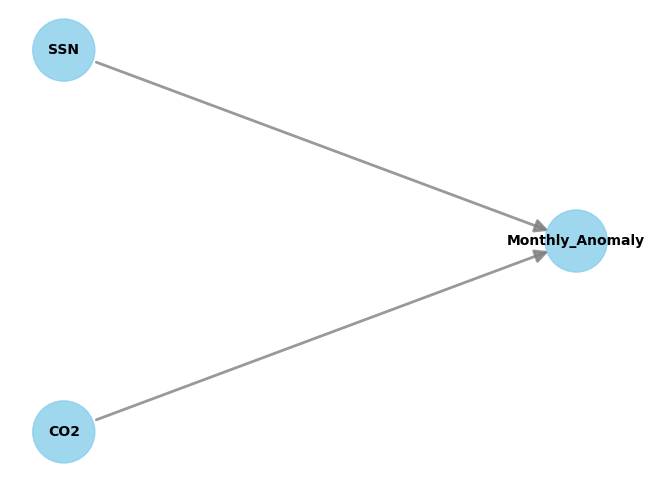

In [34]:
import dowhy
from dowhy import CausalModel


import pandas as pd

data = pd.read_csv("final_merged_dataset.csv")  



causal_graph = """
digraph {
    SSN -> Monthly_Anomaly
    CO2 -> Monthly_Anomaly
    
}
"""

model = CausalModel(
    data=data,  
    graph=causal_graph,  
    treatment='CO2',  
    outcome='Monthly_Anomaly',  
)

model.view_model()



**Extra:**

Trying Quantum models

/opt/anaconda3/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([61910])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss: 0.6330907344818115
Epoch 10, Loss: 0.5716065168380737
Epoch 20, Loss: 0.557446300983429
Epoch 30, Loss: 0.5589140057563782
Epoch 40, Loss: 0.5576602816581726
Epoch 50, Loss: 0.5571411848068237
Epoch 60, Loss: 0.5571630001068115
Epoch 70, Loss: 0.5570722222328186
Epoch 80, Loss: 0.5570754408836365
Epoch 90, Loss: 0.5570635795593262
XGBoost Mean Squared Error: 0.0955024617446955


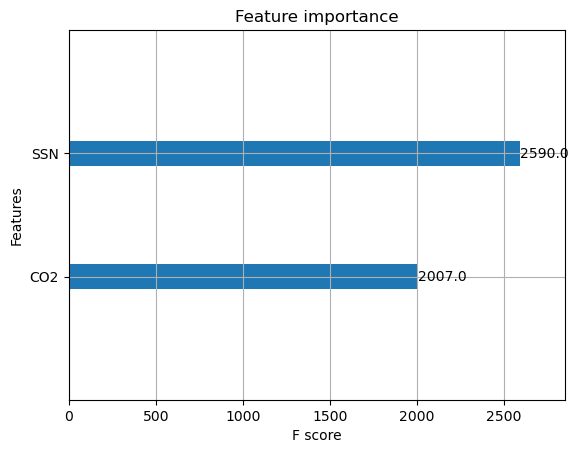

In [30]:
import torch
import torch.nn as nn
import pennylane as qml
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define the quantum layer
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits):
        super(QuantumLayer, self).__init__()
        self.n_qubits = n_qubits
        self.device = 'cpu'
        
        # Define the quantum device as an instance variable
        self.dev = qml.device("default.qubit", wires=n_qubits)

    # Define the quantum circuit inside the class
    def quantum_circuit(self, inputs):
        # Apply RY gate with the input angles for each qubit
        for i in range(self.n_qubits):
            qml.RY(inputs[i], wires=i)

        return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

    def forward(self, x):
        # Convert PyTorch tensor to NumPy
        x_numpy = x.detach().numpy()  # Convert tensor to numpy

        # Create a QNode dynamically with self.dev
        qnode = qml.QNode(self.quantum_circuit, self.dev)
        
        # Pass the data through the quantum circuit
        quantum_output = qnode(x_numpy)  

        return torch.tensor(quantum_output, dtype=torch.float32)  # Convert back to tensor


# Example of integrating this quantum layer into a classical neural network
class QuantumNN(nn.Module):
    def __init__(self, n_qubits):
        super(QuantumNN, self).__init__()
        self.quantum_layer = QuantumLayer(n_qubits)
        self.fc = nn.Linear(n_qubits, 1)  # Final linear layer for regression output

    def forward(self, x):
        # Pass through the quantum layer
        quantum_out = self.quantum_layer(x)  # This is already a tensor
        
        # Ensure the output is properly shaped for the linear layer
        quantum_out_flat = quantum_out.view(-1, self.quantum_layer.n_qubits)  # Reshape if needed
        
        output = self.fc(quantum_out_flat)  # Fully connected layer
        
        return output



# Generate synthetic data for training (replace with actual data)
final_df = pd.read_csv("final_merged_dataset.csv")

X = final_df[['SSN', 'CO2', 'Volcanic Activity']]  # control
y = final_df['Monthly Anomaly']  # outcome

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Initialize the quantum model
model = QuantumNN(n_qubits=X_train.shape[1])  # Example with 3 qubits
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop for the QuantumNN model
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()  # Clear gradients
    
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(X_train_tensor)  # Assuming X_train_tensor is your data tensor
    
    # Compute the loss
    loss = loss_fn(y_pred, y_train_tensor)  # Assuming y_train_tensor is your target
    
    # Backward pass: Compute gradient of the loss w.r.t model parameters
    loss.backward()
    
    # Update weights using optimizer
    optimizer.step()
    
    if epoch % 10 == 0:  # Print loss every 10 epochs
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Evaluate the QuantumNN model (optional)

# Train XGBoost model on the same dataset for comparison
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Fit the XGBoost model
xgb_model.fit(X_train, y_train)

# Make predictions with XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Compute MSE for XGBoost
mse = mean_squared_error(y_test, y_pred_xgb)
print(f"XGBoost Mean Squared Error: {mse}")

# Plot feature importance for XGBoost model
xgb.plot_importance(xgb_model)
plt.show()


The code ran very fast (0.3 seconds) compared to classic ann models taking more than a second or even more.

Computing time aside, it seems classic XGBoost worked well with this dataset since quantum models are still in development and may not be optimized enough 'yet' to defeat classic ml models.